#### Load the cleaned data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned_superstore.csv")
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Category,Sub-Category,Product_Name,Sales,Quantity,Discount,Profit,Year,Month,Profit_Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,0.1600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,0.3000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,0.4700
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,-0.4000
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,0.1125


#### Calculate KPIs in Python

In [3]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order_ID'].nunique()
profit_margin = (total_profit / total_sales) * 100
avg_order_value = total_sales / total_orders
avg_discount = df['Discount'].mean()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Profit Margin:", round(profit_margin, 2), "%")
print("Average Order Value:", round(avg_order_value, 2))
print("Average Discount:", round(avg_discount, 2))

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Profit Margin: 12.47 %
Average Order Value: 458.61
Average Discount: 0.16


##### Perform Segmentation Deep-Dive - Analyzing performance by:
##### -> Customer Segment
##### -> Region
##### -> Category
##### -> Discount level

#### A. Segment-wise Performance

In [4]:
segment_analysis = df.groupby('Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'nunique',
    'Discount': 'mean'
}).reset_index()

segment_analysis['Profit Margin (%)'] = (segment_analysis['Profit'] / segment_analysis['Sales']) * 100
segment_analysis

,Segment,Sales,Profit,Order_ID,Discount,Profit Margin (%)
0,Consumer,1.161401e+06,134119.2092,2586,0.158141,11.548050
1,Corporate,7.061464e+05,91979.1340,1514,0.158228,13.025506
2,Home Office,4.296531e+05,60298.6785,909,0.147128,14.034269


##### The Consumer segment contributes the highest sales and order volume, while profitability should be compared using profit margin rather than sales alone.

#### B. Region-wise Performance

In [6]:
region_analysis = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'nunique',
    'Discount': 'mean'
}).reset_index()

region_analysis['Profit Margin (%)'] = (region_analysis['Profit'] / region_analysis['Sales']) * 100
region_analysis

,Region,Sales,Profit,Order_ID,Discount,Profit Margin (%)
0,Central,501239.8908,39706.3625,1175,0.240353,7.921629
1,East,678781.2400,91522.7800,1401,0.145365,13.483399
2,South,391721.9050,46749.4303,822,0.147253,11.934342
3,West,725457.8245,108418.4489,1611,0.109335,14.944831


##### Regional analysis helps identify strong markets and underperforming regions based on both sales and profit margin.West region has the highest profit maargin

#### C. Category-wise Performance

In [7]:
category_analysis = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'nunique',
    'Discount': 'mean'
}).reset_index()

category_analysis['Profit Margin (%)'] = (category_analysis['Profit'] / category_analysis['Sales']) * 100
category_analysis

,Category,Sales,Profit,Order_ID,Discount,Profit Margin (%)
0,Furniture,741999.7953,18451.2728,1764,0.173923,2.486695
1,Office Supplies,719047.0320,122490.8008,3742,0.157285,17.035158
2,Technology,836154.0330,145454.9481,1544,0.132323,17.395712


##### Technology usually performs strongly in profit, while Furniture may show weaker profitability due to lower margins or discount impact.

#### D. Discount Impact Deep-Dive

In [8]:
def discount_band(x):
    if x == 0:
        return "No Discount"
    elif x <= 0.2:
        return "Low Discount"
    elif x <= 0.5:
        return "Medium Discount"
    else:
        return "High Discount"

df['Discount Band'] = df['Discount'].apply(discount_band)

discount_analysis = df.groupby('Discount Band').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'nunique',
    'Discount': 'mean'
}).reset_index()

discount_analysis['Profit Margin (%)'] = (discount_analysis['Profit'] / discount_analysis['Sales']) * 100
discount_analysis

,Discount Band,Sales,Profit,Order_ID,Discount,Profit Margin (%)
0,High Discount,6.422874e+04,-76559.0513,685,0.718925,-119.197502
1,Low Discount,8.465222e+05,100785.4745,2507,0.196845,11.905827
2,Medium Discount,2.985414e+05,-58817.0047,468,0.367020,-19.701456
3,No Discount,1.087908e+06,320987.6032,2644,0.000000,29.505019


##### Higher discount bands should be examined carefully because discounts can increase sales volume but reduce profitability.

### Charts for Deep-Dive Report

#### Sales and Profit by Segment


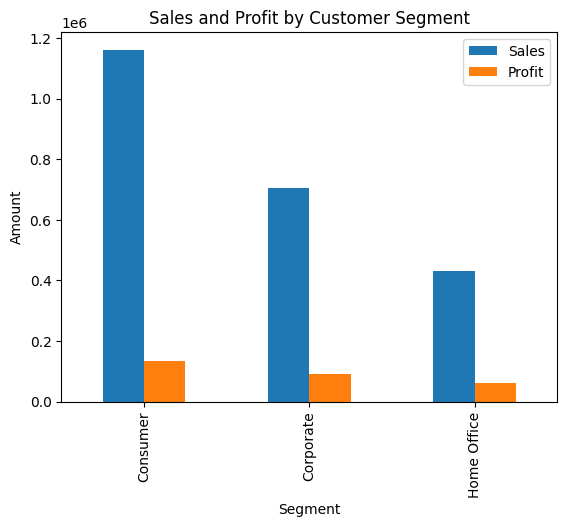

In [9]:
segment_analysis.plot(x='Segment', y=['Sales', 'Profit'], kind='bar')
plt.title("Sales and Profit by Customer Segment")
plt.ylabel("Amount")
plt.show()

#### Profit Margin by Category

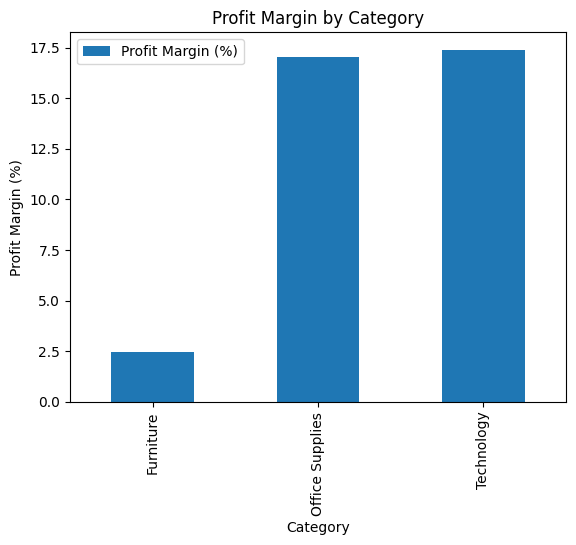

In [10]:
category_analysis.plot(x='Category', y='Profit Margin (%)', kind='bar')
plt.title("Profit Margin by Category")
plt.ylabel("Profit Margin (%)")
plt.show()

#### Sales and Profit by Region

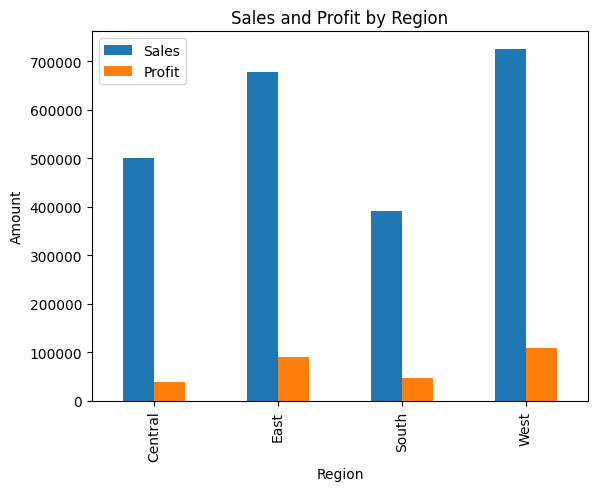

In [12]:
region_analysis.plot(x='Region', y=['Sales', 'Profit'], kind='bar')
plt.title("Sales and Profit by Region")
plt.ylabel("Amount")
plt.show()

#### Profit Margin by Discount Band

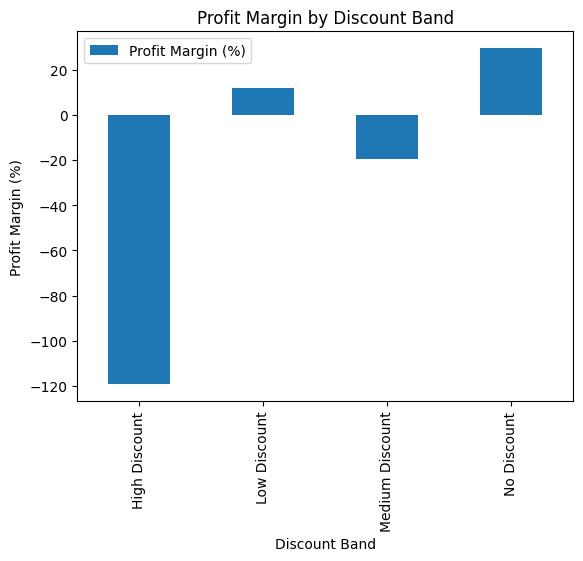

In [13]:
discount_analysis.plot(x='Discount Band', y='Profit Margin (%)', kind='bar')
plt.title("Profit Margin by Discount Band")
plt.ylabel("Profit Margin (%)")
plt.show()